# RNA para Clasificación con Iris

Demo simple de red neuronal artificial usando `sklearn.neural_network.MLPClassifier` para clasificar especies de flores.


## 1. Importar librerías


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.neural_network import MLPClassifier


## 2. Cargar dataset
El dataset Iris tiene 3 clases: setosa, versicolor y virginica.


In [2]:
data = load_iris()
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Clases:", data.target_names)
print("Primeras 5 etiquetas:", y[:5])

print(y)

Forma de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Primeras 5 etiquetas: [0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## 3. Separar entrenamiento y validación
Usamos `stratify=y` para conservar la proporción de clases.


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)


Entrenamiento: (120, 4) (120,)
Validación: (30, 4) (30,)


## 4. Estandarizar variables


In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## 5. Crear la red neuronal
Usamos `MLPClassifier` de scikit-learn para clasificación multiclase.


In [5]:
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=200,         # número máximo de iteraciones de optimización
    tol=1e-4,
    batch_size=16,
    random_state=42,
    verbose=False,
)

print("Modelo:", model)
print("Hiperparámetros:", model.get_params())

Modelo: MLPClassifier(batch_size=16, hidden_layer_sizes=(16, 8), random_state=42)
Hiperparámetros: {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 16, 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (16, 8), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


## 6. Compilar modelo


In [6]:
# Con scikit-learn no es necesario compilar el modelo por separado.


## 7. Entrenar modelo


In [7]:
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
val_acc = model.score(X_val, y_val)

print(f"Entrenamiento completado en {model.n_iter_} iteraciones")
print(f"Accuracy train: {train_acc:.4f}")
print(f"Accuracy val:   {val_acc:.4f}")

# Mostrar estructura e información de la red

def count_params(m):
    return sum(w.size + b.size for w, b in zip(m.coefs_, m.intercepts_))

print("Número de capas:", model.n_layers_)
print("Tamaño de pesos por capa:", [coef.shape for coef in model.coefs_])
print("Número total de parámetros (pesos + bias):", count_params(model))


Entrenamiento completado en 200 iteraciones
Accuracy train: 0.9833
Accuracy val:   0.9667
Número de capas: 4
Tamaño de pesos por capa: [(4, 16), (16, 8), (8, 3)]
Número total de parámetros (pesos + bias): 243


c:\Users\joset\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## 8. Evaluar modelo


In [8]:
accuracy = model.score(X_val, y_val)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9667


## 9. Predicciones y métricas


In [9]:
y_pred = model.predict(X_val)
y_pred_prob = model.predict_proba(X_val)

print("F1-score macro:", round(f1_score(y_val, y_pred, average="macro"), 4))
print("\nMatriz de confusión:")
print(confusion_matrix(y_val, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=data.target_names))


F1-score macro: 0.9666

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 10. Graficar entrenamiento


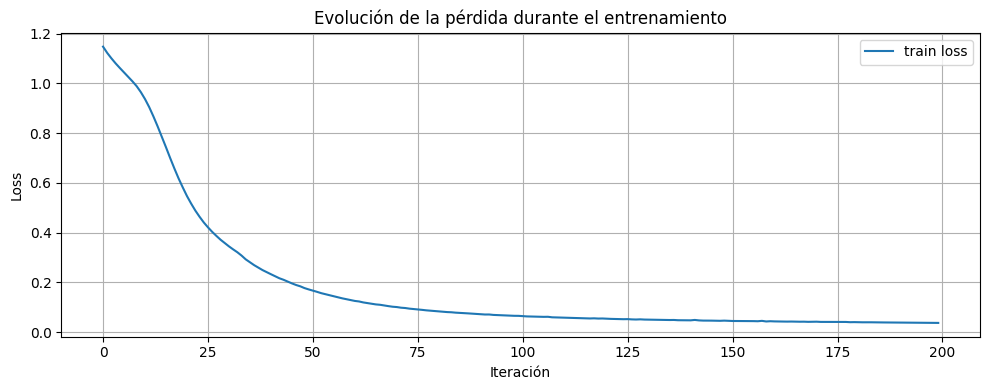

Accuracy (train): 0.9833
Accuracy (val):   0.9667


In [10]:
plt.figure(figsize=(10,4))

plt.plot(model.loss_curve_, label="train loss")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Accuracy (train): {train_acc:.4f}")
print(f"Accuracy (val):   {val_acc:.4f}")


## 11. Probar una predicción individual


In [11]:
idx = 0
muestra = X_val[idx:idx+1]
pred = model.predict(muestra)
proba = model.predict_proba(muestra)[0]
clase_pred = pred[0]
clase_real = y_val[idx]

print("Clase real:", data.target_names[clase_real])
print("Clase predicha:", data.target_names[clase_pred])
print("Probabilidades:", proba)


Clase real: setosa
Clase predicha: setosa
Probabilidades: [9.99994843e-01 5.08939261e-06 6.72274895e-08]
